In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df=pd.read_csv('../data/raw/salary_benchmark.csv')

In [5]:
df.head()

,employee_id,age,gender,education_level,job_title,seniority_level,years_experience,years_at_company,industry,company_size,location,performance_rating,num_promotions,num_certifications,remote_ratio,col_index,base_salary
0,EMP003941,26,Male,PhD,Data Scientist,Mid,0.4,0.4,Finance,Enterprise (5000+),Boston,3.0,1,3.0,0.75,1.18,154000.0
1,EMP005264,21,Male,Bachelor's,DevOps Engineer,mid-level,7.1,0.8,Tech,Startup (<50),Remote,3.0,2,1.0,0.50,1.00,163100.0
2,EMP004570,32,Female,mba,DevOps Engineer,Principal,19.8,3.8,Tech,Mid (200-1000),New York,2.0,0,0.0,0.50,1.32,256700.0
3,EMP001416,26,Male,High School,Finance Analyst,Mid,0.4,0.4,Government,Mid (200-1000),Denver,5.0,0,2.0,0.50,1.06,57800.0
4,EMP000450,21,Male,High School,ML Engineer,Mid,10.6,1.9,Consulting,Large (1000-5000),Seattle,3.0,1,2.0,0.25,1.20,133300.0


In [14]:
display(df.shape)
df.info()

df_copy = df.copy()


cat_cols = ['education_level', 'job_title', 'seniority_level']
drop_cols = ['employee_id']

fix_cols =['company_size', 'job_title']

numeric_cols = df.select_dtypes(include=np.number).columns.tolist()
# display(numeric_cols)


(5535, 17)

<class 'pandas.DataFrame'>
RangeIndex: 5535 entries, 0 to 5534
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   employee_id         5535 non-null   str    
 1   age                 5535 non-null   int64  
 2   gender              5535 non-null   str    
 3   education_level     5535 non-null   str    
 4   job_title           5535 non-null   str    
 5   seniority_level     5535 non-null   str    
 6   years_experience    5257 non-null   float64
 7   years_at_company    5535 non-null   float64
 8   industry            5535 non-null   str    
 9   company_size        5535 non-null   str    
 10  location            5535 non-null   str    
 11  performance_rating  5203 non-null   float64
 12  num_promotions      5535 non-null   int64  
 13  num_certifications  5312 non-null   float64
 14  remote_ratio        5535 non-null   float64
 15  col_index           5535 non-null   float64
 16  base_salary      

['age',
 'years_experience',
 'years_at_company',
 'performance_rating',
 'num_promotions',
 'num_certifications',
 'remote_ratio',
 'col_index',
 'base_salary']

In [15]:
df.head()

,employee_id,age,gender,education_level,job_title,seniority_level,years_experience,years_at_company,industry,company_size,location,performance_rating,num_promotions,num_certifications,remote_ratio,col_index,base_salary
0,EMP003941,26,Male,PhD,Data Scientist,Mid,0.4,0.4,Finance,Enterprise (5000+),Boston,3.0,1,3.0,0.75,1.18,154000.0
1,EMP005264,21,Male,Bachelor's,DevOps Engineer,mid-level,7.1,0.8,Tech,Startup (<50),Remote,3.0,2,1.0,0.50,1.00,163100.0
2,EMP004570,32,Female,mba,DevOps Engineer,Principal,19.8,3.8,Tech,Mid (200-1000),New York,2.0,0,0.0,0.50,1.32,256700.0
3,EMP001416,26,Male,High School,Finance Analyst,Mid,0.4,0.4,Government,Mid (200-1000),Denver,5.0,0,2.0,0.50,1.06,57800.0
4,EMP000450,21,Male,High School,ML Engineer,Mid,10.6,1.9,Consulting,Large (1000-5000),Seattle,3.0,1,2.0,0.25,1.20,133300.0


In [28]:
# df_copy['job_title'].value_counts()
# df_copy['education_level'].value_counts()
# display(df_copy['seniority_level'].value_counts())
# display(df_copy['company_size'].value_counts())

fix_cols = ['job_title', 'education_level', 'seniority_level']
missing_cols = ['performance_rating', 'num_certfications', 'years_experience']




In [35]:
for col in fix_cols:
    df_copy[col] = df_copy[col].str.strip().str.title()
    print(f"Unique values in {col}: {df_copy[col].value_counts().index.tolist()}")
    
value_map = {
    "Ml Engineer": "ML Engineer",
    "Hr Specialist": "HR Specialist",
    
    "Bachelor'S": "Bachelor",
    "Bachelors": "Bachelor",
    
    "Master'S": "Master",
    "Masters": "Master",
    "Mba": "MBA", 
    
    "Associate'S": "Associate",
    
    "Ph.D.": "PhD",
    "Phd": "PhD",
    "Doctorate": "PhD",
    
    "Mid-Level": "Mid"
}

for col in fix_cols:
    df_copy[col] = df_copy[col].replace(value_map)
    
for col in fix_cols:
    col_values = df_copy[col].value_counts()
    print(f"Cleaned unique values in {col}: {col_values.index.tolist()}")

Unique values in job_title: ['Software Engineer', 'Data Analyst', 'Data Scientist', 'Ml Engineer', 'Business Analyst', 'Finance Analyst', 'Devops Engineer', 'Product Manager', 'Marketing Analyst', 'Hr Specialist']
Unique values in education_level: ["Bachelor'S", "Master'S", "Associate'S", 'Mba', 'High School', 'Phd', 'Master', 'Bachelors', 'Masters']
Unique values in seniority_level: ['Mid', 'Senior', 'Junior', 'Lead', 'Principal', 'Mid-Level']
Cleaned unique values in job_title: ['Software Engineer', 'Data Analyst', 'Data Scientist', 'ML Engineer', 'Business Analyst', 'Finance Analyst', 'Devops Engineer', 'Product Manager', 'Marketing Analyst', 'HR Specialist']
Cleaned unique values in education_level: ['Bachelor', 'Master', 'Associate', 'MBA', 'High School', 'PhD']
Cleaned unique values in seniority_level: ['Mid', 'Senior', 'Junior', 'Lead', 'Principal']


In [37]:
df_copy.sample(10)

,employee_id,age,gender,education_level,job_title,seniority_level,years_experience,years_at_company,industry,company_size,location,performance_rating,num_promotions,num_certifications,remote_ratio,col_index,base_salary
665,EMP002250,39,Male,Master,ML Engineer,Junior,8.4,3.7,Tech,Enterprise (5000+),New York,3.0,1,3.0,0.50,1.32,195700.0
2925,EMP002760,37,Female,Bachelor,Data Analyst,Mid,NaN,5.3,Media,Enterprise (5000+),San Francisco,2.0,1,2.0,1.00,1.38,137700.0
2577,EMP000494,30,Male,Bachelor,Data Analyst,Mid,2.2,0.1,Retail,Mid (200-1000),Austin,4.0,2,2.0,0.75,1.05,81400.0
179,EMP004781,30,Male,Master,Business Analyst,Mid,3.9,1.7,Tech,Mid (200-1000),Chicago,4.0,0,1.0,0.00,1.08,132800.0
117,EMP001917,42,Female,High School,Data Analyst,Mid,35.0,5.4,Tech,Enterprise (5000+),Seattle,NaN,0,2.0,0.50,1.20,256500.0
1980,EMP005487,31,Male,Master,Data Scientist,Senior,2.9,2.9,Government,Large (1000-5000),Miami,4.0,0,0.0,0.00,1.02,96500.0
28,EMP001734,42,Male,Master,Product Manager,Mid,17.4,1.1,Healthcare,Startup (<50),Miami,4.0,2,0.0,1.00,1.02,179400.0
4935,EMP004858,41,Female,Bachelor,Product Manager,Mid,0.1,0.1,Healthcare,Large (1000-5000),Miami,NaN,0,1.0,0.00,1.02,80200.0
5474,EMP005024,50,Female,Bachelor,Data Scientist,Mid,1.6,0.7,Tech,Large (1000-5000),Remote,4.0,0,0.0,0.75,1.00,98700.0
1044,EMP005469,31,Female,Bachelor,Data Analyst,Junior,5.8,0.6,Finance,Enterprise (5000+),Atlanta,NaN,0,0.0,1.00,0.98,110500.0


In [44]:
duplicates = df_copy[df_copy.duplicated(keep=False)]

# msno.matrix(df_copy, figsize=(10, 4))
# plt.title("Missing Data Matrix")
# plt.show()

# print("\nUnique Education Levels:\n", df_copy['education_level'].unique())
# print("\nUnique Seniority Levels:\n", df_copy['seniority_level'].unique())
# print("\nUnique Job Titles:\n", df_copy['job_title'].unique())

sorted_duplicates = duplicates.sort_values(by=list(df_copy.columns))

# display(sorted_duplicates)

df_copy = df_copy.drop_duplicates()


# Exploratory Data Analysis (EDA) - Salary Benchmark

## 1. Initial Inspection & Setup
- Loaded the dataset and identified key categorical and numerical columns.
- Dropped unique identifiers (e.g., `employee_id`) which carry no predictive signal.

## 2. Data Cleaning: Categorical Inconsistencies
Standardized text features that contained mixed casing, abbreviations, and trailing spaces:
- Standardized `job_title` (e.g., "Ml Engineer" -> "ML Engineer").
- Standardized `education_level` (collapsed variants like "Bachelor'S", "Bachelors" to "Bachelor").
- Standardized `seniority_level` (e.g., "Mid-Level" to "Mid").

## 3. Handling Duplicates
- Evaluated and removed duplicate rows across the dataset (excluding `employee_id`). 


In [45]:
missing_counts = df_copy.isnull().sum()
missing_percentages = (missing_counts[missing_counts > 0] / len(df_copy)) * 100

missing_df = pd.DataFrame({
    'Missing Count': missing_counts[missing_counts > 0],
    'Percentage (%)': missing_percentages
}).sort_values(by='Missing Count', ascending=False)

display(missing_df)

,Missing Count,Percentage (%)
performance_rating,330,6.0
years_experience,275,5.0
num_certifications,220,4.0


### Missing Values Strategy

* **`years_experience` (~5% missing):** Missing mostly for contractors and employees from traditional paths. We will use KNN imputation considering `age` and `years_at_company` as neighbors, or median imputation grouped by `seniority_level`.
* **`performance_rating` (~6% missing):** Missing primarily because new hires (`years_at_company < 1`) haven't been reviewed yet. We will impute with 3.0 (neutral) for these new hires, and use the median for the rest.
* **`num_certifications` (~4% missing):** Missing values don't follow a strict structural pattern. We'll impute with the median grouped by `job_title`, as certification norms vary heavily by role (e.g., Data Scientist vs. HR Specialist).
* this is pretty accurate you can almost know the data is still synthetic but still cool

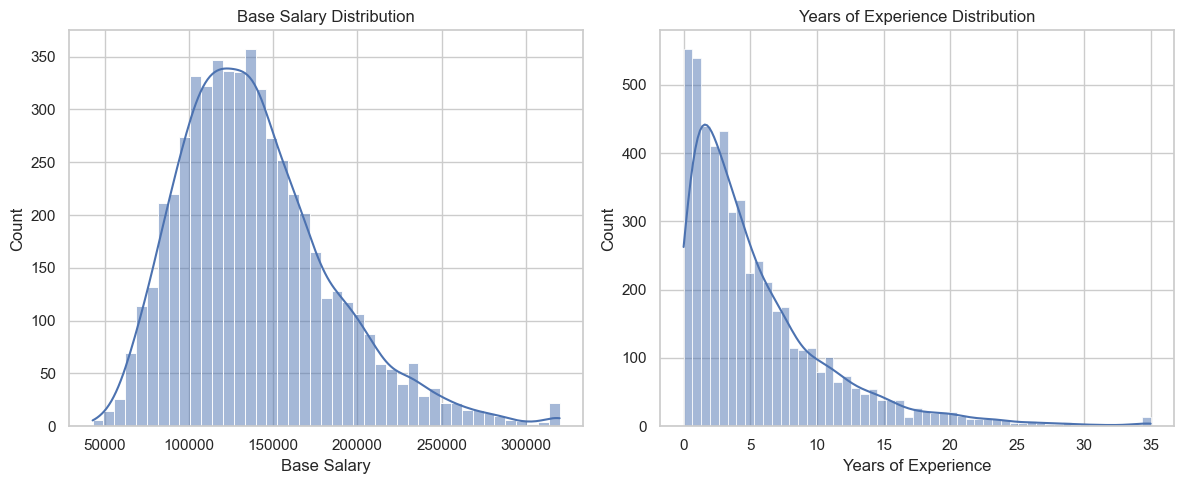

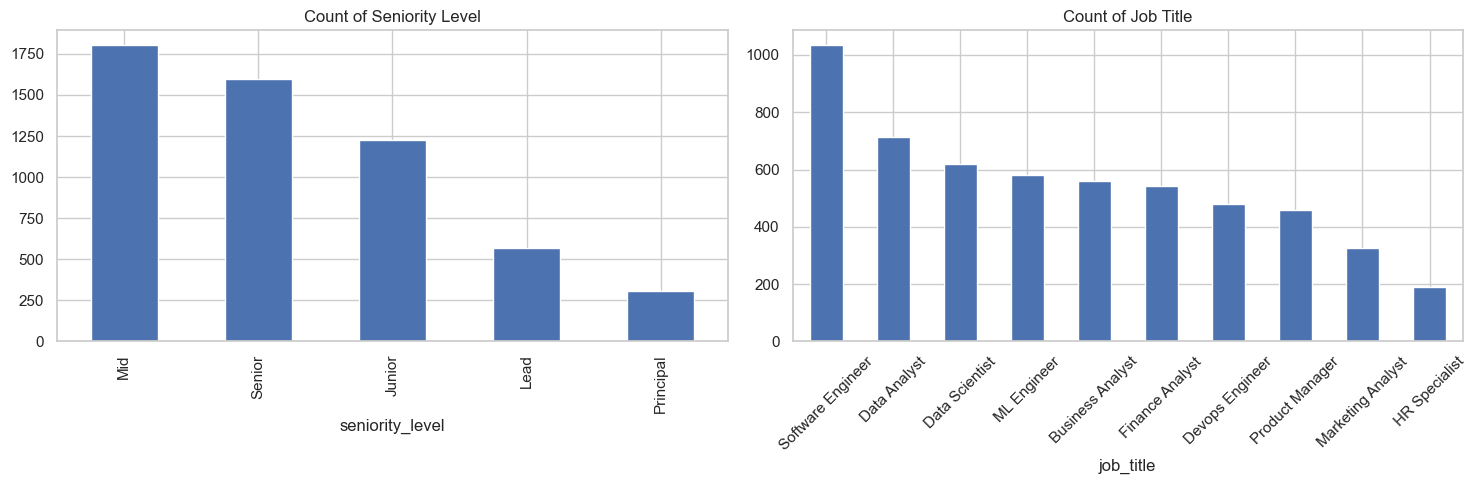

In [53]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(df_copy['base_salary'], kde=True, ax=ax[0])
ax[0].set_title("Base Salary Distribution")
ax[0].set_xlabel("Base Salary")

sns.histplot(df_copy['years_experience'], kde=True, ax=ax[1])
ax[1].set_title("Years of Experience Distribution")
ax[1].set_xlabel("Years of Experience")

plt.tight_layout()
plt.savefig('../reports/figures/salary-experience-distribution.png')
plt.show()


fig, ax = plt.subplots(1, 2, figsize=(15, 5))
df_copy['seniority_level'].value_counts().plot(kind='bar', ax=ax[0], title='Count of Seniority Level')
df_copy['job_title'].value_counts().plot(kind='bar', ax=ax[1], title='Count of Job Title')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('../reports/figures/seniority-jobtitle-distribution.png')
plt.show()

### Chart explenation

* **The Pay & The People:** Most folks are making between \$100k and \$150k and are relatively early in their careers (0–5 years). There is a long tail, though—a few veterans are pulling in over \$300k!  
* **The Corporate Ladder:** The seniority breakdown is bottom-heavy, exactly as you'd expect. Mid-level and Senior workers make up the bulk of the crowd, keeping the Lead and Principal spots pretty exclusive.  
* **Who's Here:** Software Engineers completely dominate the dataset. They're backed up by a solid squad of data pros, while operations roles like HR make up a tiny fraction.

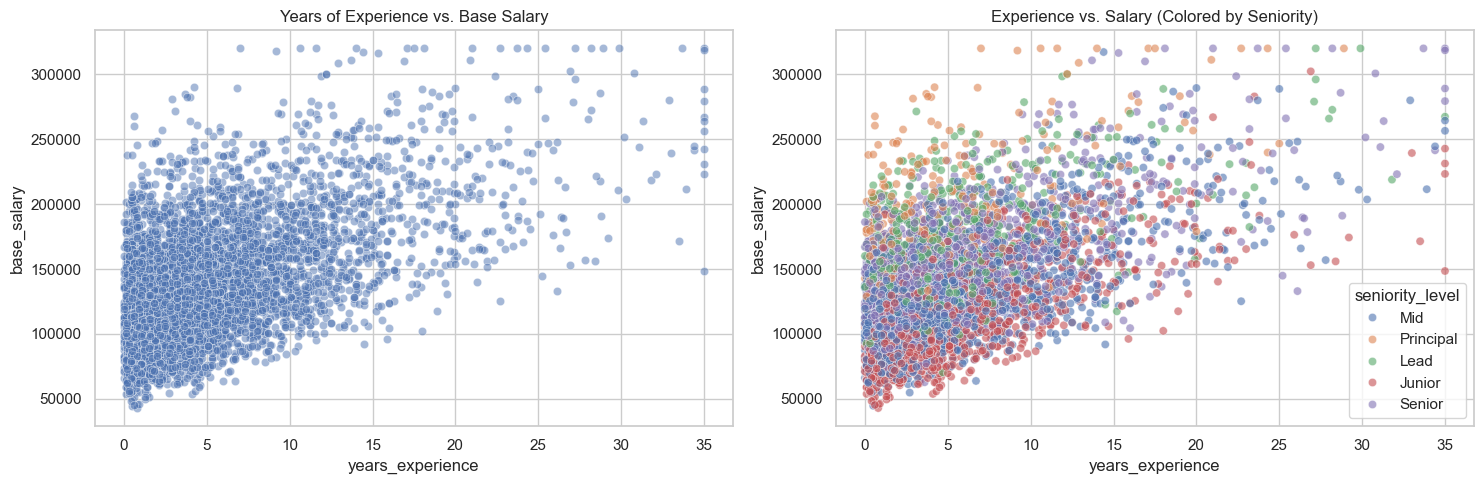

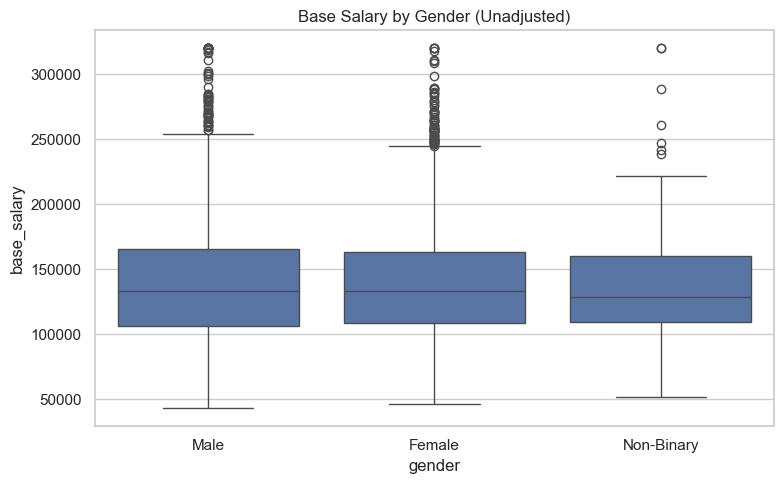

In [66]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_copy, x='seniority_level', y='base_salary', order=['Junior', 'Mid', 'Senior', 'Lead', 'Principal'])
plt.title("Base Salary by Seniority Level")
plt.tight_layout()
plt.savefig('../reports/figures/salary-by-seniority.png')
plt.close()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df_copy, x='industry', y='base_salary')
plt.title("Base Salary by Industry")
plt.tight_layout()
plt.savefig('../reports/figures/salary-by-industry.png')
plt.close()



#Scatter plot of base salary vs years of experience

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.scatterplot(data=df_copy, x='years_experience', y='base_salary', alpha=0.5, ax=ax[0])
ax[0].set_title('Years of Experience vs. Base Salary')

sns.scatterplot(data=df_copy, x='years_experience', y='base_salary', hue='seniority_level', alpha=0.6, ax=ax[1])
ax[1].set_title('Experience vs. Salary (Colored by Seniority)')

plt.tight_layout()
plt.savefig('../reports/figures/salary-experience-scatter.png')
plt.show()


plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='gender', y='base_salary')
plt.title("Base Salary by Gender (Unadjusted)")
plt.tight_layout()
plt.savefig('../reports/figures/salary-by-gender-unadjusted.png')
plt.show()

### Boxplot Insights: Salary Drivers & Outliers

* **Seniority & Industry:** Base pay climbs predictably as seniority increases, but the variance also widens at the top. **Tech** and **Finance** are the highest-paying sectors with the widest pay bands, whereas **Government** and **Retail** are the lowest and tightest.
* **Valid Outliers:** There are many upper-bound outliers (e.g., Junior roles exceeding \$200k). These are likely valid corner cases—like Tech engineers in high-cost cities—rather than data errors. 
* **Modeling Strategy:** Because these outliers represent real salaries, **we will not drop them**. Instead, we'll favor robust tree-based models (Random Forest, XGBoost) or apply a log transformation (`np.log1p`) to the target variable if using linear models.

### Scatter & Demographic Insights

* **Experience vs. Pay (The Scatter Plots):** While there is a positive correlation between years of experience and base salary, the variance is huge at every level. However, once we color by **Seniority Level**, clear stratified bands emerge. This tells us that your job title (Seniority) is a much stronger predictor of your salary band than simply how many years you've been working.
* **Gender Equity (Unadjusted):** Looking at base salary by gender without controlling for other variables, the distributions are remarkably similar across Male, Female, and Non-Binary groups. The medians, interquartile ranges, and outlier patterns map closely to one another, suggesting no obvious systemic salary bias at this high-level, unadjusted view.

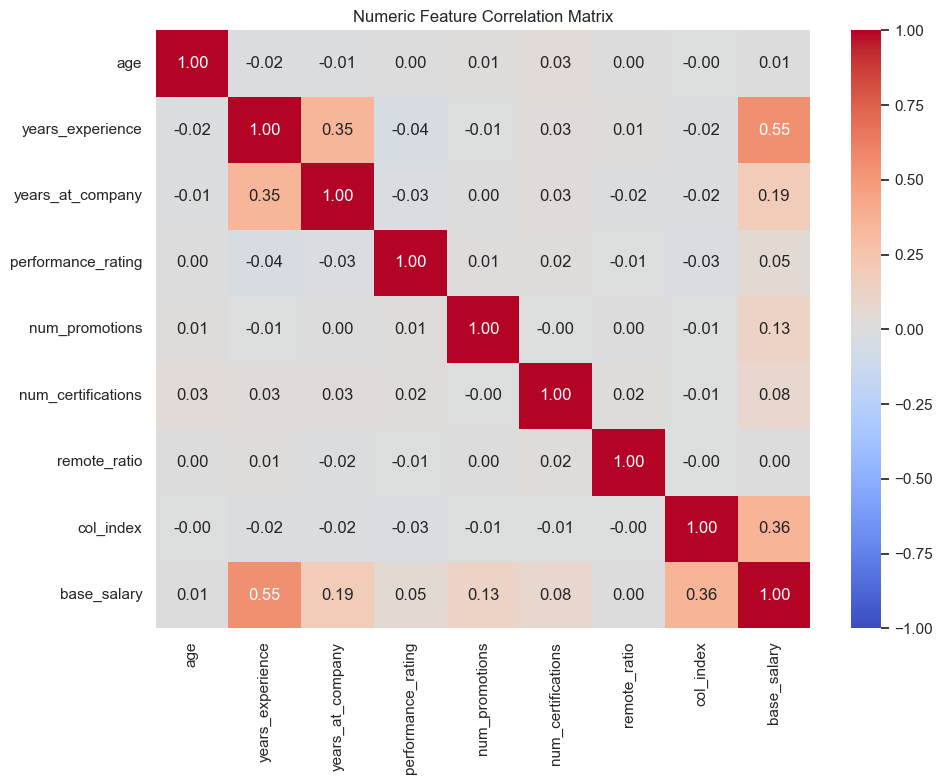

In [68]:
plt.figure(figsize=(10, 8))
numeric_df = df.select_dtypes(include=[np.number])
corr_matrix = numeric_df.corr()

sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title("Numeric Feature Correlation Matrix")
plt.tight_layout()
plt.savefig('../reports/figures/correlation-matrix.png')
plt.show()

### Correlation Matrix Insights

* **Strongest Numeric Predictors:** `years_experience` (0.55) has the strongest positive linear correlation with our target, `base_salary`. Cost of living (`col_index` at 0.36) is the second most important numerical driver, showing that location heavily impacts compensation regardless of other factors. 

* **Surprising Non-Factors:** Interestingly, `performance_rating` (0.05), `remote_ratio` (0.00), and `age` (0.01) have almost zero linear relationship with base pay. This indicates you don't automatically get paid more just for being older, working in an office, or having a slightly higher performance score.

* **Low Multicollinearity:** The independent variables are generally not highly correlated with each other. The strongest relationship is between `years_experience` and `years_at_company` (0.35), which is intuitive. Since no correlations are dangerously high (e.g., > 0.80), we won't need to aggressively drop numerical features to satisfy linear model assumptions.

In [73]:
benchmark_table = df_copy.pivot_table(
    values='base_salary', 
    index='job_title', 
    columns='seniority_level', 
    aggfunc='mean'
).round(0)
order = ['Junior', 'Mid', 'Senior', 'Lead', 'Principal']
display(benchmark_table[order])

seniority_level,Junior,Mid,Senior,Lead,Principal
job_title,,,,,
Business Analyst,114761.0,133962.0,154868.0,177675.0,194483.0
Data Analyst,110875.0,129874.0,147573.0,163907.0,202445.0
Data Scientist,117592.0,130974.0,145248.0,172044.0,185011.0
Devops Engineer,114313.0,132725.0,147382.0,164612.0,202403.0
Finance Analyst,112897.0,124177.0,149791.0,177997.0,206577.0
HR Specialist,113166.0,119504.0,146547.0,176840.0,183160.0
ML Engineer,113393.0,124571.0,149073.0,172238.0,209450.0
Marketing Analyst,113924.0,125809.0,152135.0,179293.0,206550.0
Product Manager,117434.0,128407.0,150404.0,164353.0,191133.0


### Salary Benchmark Table Insights

* **Predictable Pay Bumps:** Across every single job title, there is a clear, standard progression in pay as you move up the ranks (Junior -> Mid -> Senior -> Lead -> Principal). On average, moving up a tier nets a very reliable boost in base pay.

* **Level Playing Field at the Bottom:** Entry-level pay is remarkably tight. Whether you are an HR Specialist (\$113k), a Data Scientist (\$117k), or a Software Engineer (\$113k), Junior salaries almost universally start in the \$110k–\$117k range. 

* **The Gap Widens at the Top:** The pay variance between different roles becomes much more obvious at the executive end. Technical and quantitative roles pull ahead at the Principal level (e.g., ML Engineers and Software Engineers nearing \$210k), while operational roles like HR Specialists cap out noticeably lower (around \$183k).